# Multi-Class DDoS Detection: ML & DL Model Comparison

**ProDDoS-NFV Framework — Comprehensive Model Benchmarking**

This notebook trains and evaluates **8 Machine Learning** and **2 Deep Learning** models on the **CIC-DDoS 2019** dataset for multi-class DDoS attack classification (13 classes).

### ML Models
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Support Vector Machine (SVM)
5. K-Nearest Neighbors (KNN)
6. Gradient Boosting
7. XGBoost
8. LightGBM

### DL Models (PyTorch)
9. Simple DNN (2 hidden layers)
10. Deep DNN (4 hidden layers + Dropout + BatchNorm)

### Evaluation Metrics
- Accuracy, Precision, Recall, F1-Score (Weighted & Macro)
- Per-class classification reports
- Confusion matrices
- Training time comparison
- ROC-AUC curves for best models

In [3]:
# ═══════════════════════════════════════════════════════════════
# Cell 1: Import Required Libraries
# ═══════════════════════════════════════════════════════════════
import os, gc, warnings, time, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Scikit-learn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score,
    precision_recall_fscore_support, roc_auc_score, roc_curve, auc
)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

# Boosting libraries
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

# PyTorch (Deep Learning)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ── Config ─────────────────────────────────────────────────────
BASE_DIR    = Path(r"d:\Khóa luận\Dataset")
MODEL_DIR   = Path(r"d:\Khóa luận\Src\models")
MODEL_DIR.mkdir(exist_ok=True)

CHUNK_SIZE  = 200_000
SAMPLE_FRAC = 0.05
LABEL_COL   = "Label"
RANDOM_STATE = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print(f"PyTorch: {torch.__version__} | Device: {DEVICE}")
print("Scikit-learn, LightGBM, XGBoost, CatBoost loaded successfully")

PyTorch: 2.8.0+cpu | Device: cpu
Scikit-learn, LightGBM, XGBoost, CatBoost loaded successfully


## 1. Load and Explore the Dataset
Memory-efficient chunked loading of the CIC-DDoS 2019 dataset (~30 GB) with 5% stratified sampling.

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Cell 2: Load Dataset (Memory-Efficient Chunked Loading)
# ═══════════════════════════════════════════════════════════════
CSV_DIRS = [
    BASE_DIR / "CSV-01-12" / "01-12",
    BASE_DIR / "CSV-03-11" / "03-11",
]
all_csv = []
for d in CSV_DIRS:
    all_csv.extend(sorted(d.glob("*.csv")))

def reduce_mem(df):
    for col in df.select_dtypes(include=["float64"]).columns:
        df[col] = df[col].astype("float32")
    for col in df.select_dtypes(include=["int64"]).columns:
        df[col] = df[col].astype("int32")
    return df

sample_frames = []
class_counts = {}

for csv_path in all_csv:
    local_samples = []
    reader = pd.read_csv(
        csv_path, chunksize=CHUNK_SIZE,
        low_memory=False, encoding="utf-8", on_bad_lines="skip"
    )
    for chunk in reader:
        chunk.columns = chunk.columns.str.strip()
        chunk = reduce_mem(chunk)
        chunk.replace([np.inf, -np.inf], np.nan, inplace=True)
        chunk.dropna(how="all", axis=1, inplace=True)
        if LABEL_COL in chunk.columns:
            for label, cnt in chunk[LABEL_COL].value_counts().items():
                label = str(label).strip()
                class_counts[label] = class_counts.get(label, 0) + cnt
        n_sample = max(1, int(len(chunk) * SAMPLE_FRAC))
        local_samples.append(chunk.sample(n=n_sample, random_state=RANDOM_STATE))
        del chunk; gc.collect()
    sample_frames.append(pd.concat(local_samples, ignore_index=True))
    print(f"  Loaded {csv_path.name}")
    del local_samples; gc.collect()

eda_df = pd.concat(sample_frames, ignore_index=True)
del sample_frames; gc.collect()

print(f"\nSample size: {len(eda_df):,} rows x {eda_df.shape[1]} columns")
print(f"RAM: {eda_df.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"\nClass distribution (full dataset):")
for label, cnt in sorted(class_counts.items(), key=lambda x: -x[1]):
    print(f"  {label:30s} {cnt:>12,}")

  Loaded DrDoS_DNS.csv
  Loaded DrDoS_LDAP.csv


## 2. Data Preprocessing and Feature Engineering

Classes: 19 — ['BENIGN', 'DrDoS_DNS', 'DrDoS_LDAP', 'DrDoS_MSSQL', 'DrDoS_NTP', 'DrDoS_NetBIOS', 'DrDoS_SNMP', 'DrDoS_SSDP', 'DrDoS_UDP', 'LDAP', 'MSSQL', 'NetBIOS', 'Portmap', 'Syn', 'TFTP', 'UDP', 'UDP-lag', 'UDPLag', 'WebDDoS']
Features after selection: 40
Dataset shape: (3521374, 41)


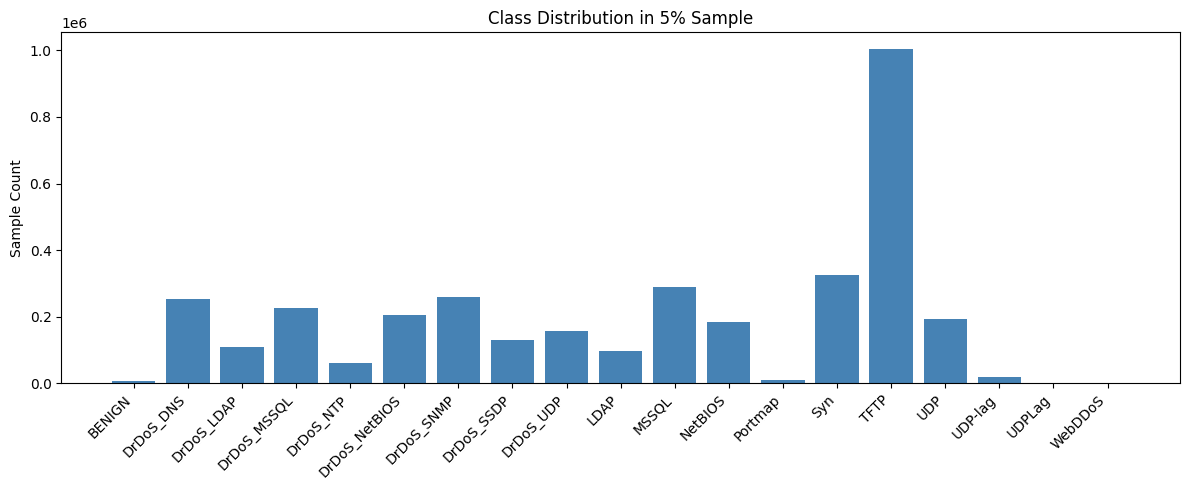

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Cell 3: Preprocessing — Clean, Encode, Select Features
# ═══════════════════════════════════════════════════════════════
df = eda_df.copy()

# Drop metadata columns
COLS_TO_DROP = [
    "Flow ID", "Source IP", "Destination IP",
    "Source Port", "Destination Port", "Timestamp",
    "SimillarHTTP",
]
df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns],
        inplace=True, errors="ignore")

# Clean Inf / NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

# Encode multi-class labels
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip()
le = LabelEncoder()
df["target"] = le.fit_transform(df[LABEL_COL])
class_names = le.classes_.tolist()
n_classes = len(class_names)
df.drop(columns=[LABEL_COL], inplace=True)

# Remove zero-variance features
feat_cols = df.select_dtypes(include=[np.number]).columns.drop("target", errors="ignore")
vt = VarianceThreshold(threshold=0.0)
vt.fit(df[feat_cols])
low_var = feat_cols[~vt.get_support()].tolist()
df.drop(columns=low_var, inplace=True, errors="ignore")

# Remove highly correlated features (|r| > 0.95)
feat_cols = df.select_dtypes(include=[np.number]).columns.drop("target", errors="ignore")
corr_mat = df[feat_cols].corr().abs()
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.95)]
df.drop(columns=to_drop, inplace=True, errors="ignore")

feat_cols = [c for c in df.columns if c != "target"]
print(f"Classes: {n_classes} — {class_names}")
print(f"Features after selection: {len(feat_cols)}")
print(f"Dataset shape: {df.shape}")

# Show class distribution in sample
class_dist = df["target"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(n_classes), [class_dist.get(i, 0) for i in range(n_classes)], color="steelblue")
ax.set_xticks(range(n_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_ylabel("Sample Count")
ax.set_title("Class Distribution in 5% Sample")
plt.tight_layout()
plt.show()

## 3. Train-Test Split and Feature Scaling

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Cell 4: Train/Test Split + Scaling
# ═══════════════════════════════════════════════════════════════
X = df[feat_cols].values.astype("float32")
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train class counts: {np.bincount(y_train)}")
print(f"Test  class counts: {np.bincount(y_test)}")

# Results storage
results = {}  # {model_name: {accuracy, precision, recall, f1_weighted, f1_macro, train_time}}

Train: (2817099, 40)  |  Test: (704275, 40)
Train class counts: [  4483 202844  87204 180902  48106 163734 206397 104417 125362  76597
 231484 146310   7480 259035 803346 154641  14659     78     20]
Test  class counts: [  1120  50711  21801  45225  12027  40934  51599  26104  31341  19149
  57871  36578   1870  64759 200837  38660   3665     19      5]


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Helper: Train + Evaluate any sklearn-compatible model
# ═══════════════════════════════════════════════════════════════
def train_and_evaluate(name, model, X_tr, X_te, y_tr, y_te):
    """Train a model, evaluate it, store results, and print a summary."""
    print(f"\n{'='*60}")
    print(f"  Training: {name}")
    print(f"{'='*60}")
    
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0
    
    y_pred = model.predict(X_te)
    
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_te, y_pred, average="weighted", zero_division=0)
    f1_w = f1_score(y_te, y_pred, average="weighted", zero_division=0)
    f1_m = f1_score(y_te, y_pred, average="macro", zero_division=0)
    
    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 (Weighted)": f1_w,
        "F1 (Macro)": f1_m,
        "Train Time (s)": round(train_time, 2),
    }
    
    print(f"  Accuracy:      {acc:.4f}")
    print(f"  Precision (W): {prec:.4f}")
    print(f"  Recall (W):    {rec:.4f}")
    print(f"  F1 Weighted:   {f1_w:.4f}")
    print(f"  F1 Macro:      {f1_m:.4f}")
    print(f"  Train Time:    {train_time:.2f}s")
    
    return model, y_pred

---
# Part A: Machine Learning Models
---

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Model 1: Logistic Regression
# ═══════════════════════════════════════════════════════════════
lr_model, lr_pred = train_and_evaluate(
    "Logistic Regression",
    LogisticRegression(
        max_iter=1000, multi_class="multinomial",
        solver="lbfgs", n_jobs=-1, random_state=RANDOM_STATE
    ),
    X_train, X_test, y_train, y_test
)


  Training: Logistic Regression
  Accuracy:      0.6064
  Precision (W): 0.5503
  Recall (W):    0.6064
  F1 Weighted:   0.5297
  F1 Macro:      0.3713
  Train Time:    598.11s


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Model 2: Decision Tree
# ═══════════════════════════════════════════════════════════════
dt_model, dt_pred = train_and_evaluate(
    "Decision Tree",
    DecisionTreeClassifier(
        max_depth=20, min_samples_leaf=5,
        random_state=RANDOM_STATE
    ),
    X_train, X_test, y_train, y_test
)


  Training: Decision Tree
  Accuracy:      0.7475
  Precision (W): 0.7353
  Recall (W):    0.7475
  F1 Weighted:   0.7283
  F1 Macro:      0.5461
  Train Time:    37.13s


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Model 3: Random Forest
# ═══════════════════════════════════════════════════════════════
rf_model, rf_pred = train_and_evaluate(
    "Random Forest",
    RandomForestClassifier(
        n_estimators=200, max_depth=20, min_samples_leaf=5,
        n_jobs=-1, random_state=RANDOM_STATE
    ),
    X_train, X_test, y_train, y_test
)


  Training: Random Forest
  Accuracy:      0.7480
  Precision (W): 0.7372
  Recall (W):    0.7480
  F1 Weighted:   0.7201
  F1 Macro:      0.5223
  Train Time:    164.00s


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Model 4: Extra Trees (similar to RF but more randomized splits)
# ═══════════════════════════════════════════════════════════════
et_model, et_pred = train_and_evaluate(
    "Extra Trees",
    ExtraTreesClassifier(
        n_estimators=200, max_depth=20, min_samples_leaf=5,
        n_jobs=-1, random_state=RANDOM_STATE
    ),
    X_train, X_test, y_train, y_test
)


  Training: Extra Trees
  Accuracy:      0.6745
  Precision (W): 0.6702
  Recall (W):    0.6745
  F1 Weighted:   0.6030
  F1 Macro:      0.4142
  Train Time:    166.70s


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Model 6: Linear SVM (LinearSVC — fast for large datasets)
# ═══════════════════════════════════════════════════════════════
svm_model, svm_pred = train_and_evaluate(
    "Linear SVM",
    LinearSVC(
        max_iter=2000, multi_class="ovr",
        random_state=RANDOM_STATE
    ),
    X_train, X_test, y_train, y_test
)


  Training: Linear SVM


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Model 7: LightGBM
# ═══════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"  Training: LightGBM")
print(f"{'='*60}")

t0 = time.time()
dtrain = lgb.Dataset(X_train, label=y_train)
dval = lgb.Dataset(X_test, label=y_test, reference=dtrain)

lgb_params = {
    "objective": "multiclass",
    "num_class": n_classes,
    "metric": "multi_logloss",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "min_child_samples": 50,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "n_jobs": -1,
    "verbose": -1,
    "is_unbalance": True,
}

lgb_model = lgb.train(
    lgb_params, dtrain,
    num_boost_round=300,
    valid_sets=[dval],
    callbacks=[lgb.log_evaluation(period=100), lgb.early_stopping(30)],
)
lgb_time = time.time() - t0

y_prob_lgb = lgb_model.predict(X_test)
lgb_pred = np.argmax(y_prob_lgb, axis=1)

acc = accuracy_score(y_test, lgb_pred)
prec = precision_score(y_test, lgb_pred, average="weighted", zero_division=0)
rec = recall_score(y_test, lgb_pred, average="weighted", zero_division=0)
f1_w = f1_score(y_test, lgb_pred, average="weighted", zero_division=0)
f1_m = f1_score(y_test, lgb_pred, average="macro", zero_division=0)

results["LightGBM"] = {
    "Accuracy": acc, "Precision": prec, "Recall": rec,
    "F1 (Weighted)": f1_w, "F1 (Macro)": f1_m, "Train Time (s)": round(lgb_time, 2),
}
print(f"  Accuracy: {acc:.4f} | F1(W): {f1_w:.4f} | F1(M): {f1_m:.4f} | Time: {lgb_time:.2f}s")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Model 8: XGBoost
# ═══════════════════════════════════════════════════════════════
xgb_model, xgb_pred = train_and_evaluate(
    "XGBoost",
    xgb.XGBClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        objective="multi:softprob", num_class=n_classes,
        eval_metric="mlogloss", use_label_encoder=False,
        tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
    ),
    X_train, X_test, y_train, y_test
)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Model 9: CatBoost
# ═══════════════════════════════════════════════════════════════
cat_model, cat_pred = train_and_evaluate(
    "CatBoost",
    CatBoostClassifier(
        iterations=300, depth=8, learning_rate=0.05,
        loss_function="MultiClass", auto_class_weights="Balanced",
        verbose=0, random_seed=RANDOM_STATE,
    ),
    X_train, X_test, y_train, y_test
)

---
## 4. ML Models — Performance Comparison
---

In [ ]:
# ═══════════════════════════════════════════════════════════════
# ML Models Comparison Table + Bar Chart
# ═══════════════════════════════════════════════════════════════
ml_results_df = pd.DataFrame(results).T.sort_values("F1 (Weighted)", ascending=False)
ml_results_df.index.name = "Model"

print("=" * 80)
print("  ML MODELS — PERFORMANCE COMPARISON")
print("=" * 80)
print(ml_results_df.to_string(float_format=lambda x: f"{x:.4f}"))
print(f"\n  Best ML Model: {ml_results_df.index[0]} "
      f"(F1-W: {ml_results_df.iloc[0]['F1 (Weighted)']:.4f})")

# ── Bar Chart ─────────────────────────────────────────────────
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 (Weighted)", "F1 (Macro)"]
fig, ax = plt.subplots(figsize=(16, 7))

x = np.arange(len(ml_results_df))
width = 0.15
colors = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63", "#9C27B0"]

for i, metric in enumerate(metrics_to_plot):
    bars = ax.bar(x + i * width, ml_results_df[metric], width,
                  label=metric, color=colors[i], alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(ml_results_df.index, rotation=30, ha="right", fontsize=11)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("ML Models — Performance Comparison (CIC-DDoS 2019)", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.set_ylim(0, 1.08)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_DIR / "ml_models_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Training Time Chart ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
times = ml_results_df["Train Time (s)"]
bars = ax.barh(ml_results_df.index, times, color="steelblue", alpha=0.8)
ax.set_xlabel("Training Time (seconds)")
ax.set_title("ML Models — Training Time Comparison")
for bar, t in zip(bars, times):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{t:.1f}s", va="center", fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(MODEL_DIR / "ml_training_time.png", dpi=150, bbox_inches="tight")
plt.show()

---
# Part B: Deep Learning Models (PyTorch)
---

In [ ]:
# ═══════════════════════════════════════════════════════════════
# DL Setup: PyTorch DataLoaders
# ═══════════════════════════════════════════════════════════════
X_train_t = torch.FloatTensor(X_train).to(DEVICE)
X_test_t  = torch.FloatTensor(X_test).to(DEVICE)
y_train_t = torch.LongTensor(y_train).to(DEVICE)
y_test_t  = torch.LongTensor(y_test).to(DEVICE)

BATCH_SIZE = 1024
train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t, y_test_t)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

input_dim = X_train.shape[1]
print(f"Input dim: {input_dim} | Classes: {n_classes} | Device: {DEVICE}")
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")


def train_pytorch_model(model, name, n_epochs=50, lr=1e-3, patience=10):
    """Train a PyTorch model with early stopping and return history."""
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    best_state = None
    no_improve = 0
    
    t0 = time.time()
    for epoch in range(n_epochs):
        # Train
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            total += xb.size(0)
        
        train_loss /= total
        train_acc = correct / total
        
        # Validate
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                out = model(xb)
                loss = criterion(out, yb)
                val_loss += loss.item() * xb.size(0)
                correct += (out.argmax(1) == yb).sum().item()
                total += xb.size(0)
        
        val_loss /= total
        val_acc = correct / total
        scheduler.step(val_loss)
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}/{n_epochs}: "
                  f"Train Loss={train_loss:.4f} Acc={train_acc:.4f} | "
                  f"Val Loss={val_loss:.4f} Acc={val_acc:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break
    
    train_time = time.time() - t0
    model.load_state_dict(best_state)
    
    # Final evaluation
    model.eval()
    all_preds = []
    with torch.no_grad():
        for xb, yb in test_loader:
            out = model(xb)
            all_preds.append(out.argmax(1).cpu().numpy())
    
    y_pred = np.concatenate(all_preds)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1_w = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    f1_m = f1_score(y_test, y_pred, average="macro", zero_division=0)
    
    results[name] = {
        "Accuracy": acc, "Precision": prec, "Recall": rec,
        "F1 (Weighted)": f1_w, "F1 (Macro)": f1_m,
        "Train Time (s)": round(train_time, 2),
    }
    
    print(f"\n  {name} Results:")
    print(f"  Accuracy: {acc:.4f} | F1(W): {f1_w:.4f} | F1(M): {f1_m:.4f} | Time: {train_time:.1f}s")
    
    return model, y_pred, history

In [ ]:
# ═══════════════════════════════════════════════════════════════
# DL Model 1: Simple DNN (2 Hidden Layers)
# ═══════════════════════════════════════════════════════════════
class SimpleDNN(nn.Module):
    def __init__(self, input_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, n_classes),
        )
    
    def forward(self, x):
        return self.net(x)

print("=" * 60)
print("  DL Model 1: Simple DNN (2 hidden layers: 256 -> 128)")
print("=" * 60)

simple_dnn = SimpleDNN(input_dim, n_classes)
print(f"  Parameters: {sum(p.numel() for p in simple_dnn.parameters()):,}")

simple_model, simple_pred, simple_hist = train_pytorch_model(
    simple_dnn, "DNN-Simple", n_epochs=80, lr=1e-3, patience=15
)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# DL Model 2: Deep DNN (4 Hidden Layers + Dropout + BatchNorm)
# ═══════════════════════════════════════════════════════════════
class DeepDNN(nn.Module):
    def __init__(self, input_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            
            nn.Linear(64, n_classes),
        )
    
    def forward(self, x):
        return self.net(x)

print("=" * 60)
print("  DL Model 2: Deep DNN (4 layers: 512->256->128->64 + BN + Dropout)")
print("=" * 60)

deep_dnn = DeepDNN(input_dim, n_classes)
print(f"  Parameters: {sum(p.numel() for p in deep_dnn.parameters()):,}")

deep_model, deep_pred, deep_hist = train_pytorch_model(
    deep_dnn, "DNN-Deep", n_epochs=100, lr=1e-3, patience=15
)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# DL Training Curves — Loss & Accuracy
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, (name, hist) in enumerate([("DNN-Simple", simple_hist), ("DNN-Deep", deep_hist)]):
    # Loss
    ax = axes[0, idx]
    ax.plot(hist["train_loss"], label="Train Loss", color="blue")
    ax.plot(hist["val_loss"], label="Val Loss", color="red")
    ax.set_title(f"{name} — Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Accuracy
    ax = axes[1, idx]
    ax.plot(hist["train_acc"], label="Train Acc", color="blue")
    ax.plot(hist["val_acc"], label="Val Acc", color="red")
    ax.set_title(f"{name} — Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Deep Learning Training Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(MODEL_DIR / "dl_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

---
# Part C: Final Comparison — All Models (ML + DL)
---

In [ ]:
# ═══════════════════════════════════════════════════════════════
# FINAL COMPARISON TABLE — All 11 Models
# ═══════════════════════════════════════════════════════════════
all_results_df = pd.DataFrame(results).T.sort_values("F1 (Weighted)", ascending=False)
all_results_df.index.name = "Model"

# Tag model type
all_results_df["Type"] = all_results_df.index.map(
    lambda x: "DL" if "DNN" in x else "ML"
)

print("=" * 90)
print("  COMPLETE MODEL COMPARISON — CIC-DDoS 2019 Multi-Class (13 classes)")
print("=" * 90)
print(all_results_df.to_string(float_format=lambda x: f"{x:.4f}"))
print()

best_model = all_results_df.index[0]
best_f1 = all_results_df.iloc[0]["F1 (Weighted)"]
best_type = all_results_df.iloc[0]["Type"]
print(f"  BEST OVERALL: {best_model} ({best_type}) — F1 Weighted: {best_f1:.4f}")

# Best ML vs Best DL
best_ml = all_results_df[all_results_df["Type"] == "ML"].index[0]
best_dl = all_results_df[all_results_df["Type"] == "DL"].index[0]
print(f"  Best ML: {best_ml} (F1-W: {results[best_ml]['F1 (Weighted)']:.4f})")
print(f"  Best DL: {best_dl} (F1-W: {results[best_dl]['F1 (Weighted)']:.4f})")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Final Bar Chart — All Models Ranked by F1 (Weighted)
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Chart 1: F1 scores (Weighted + Macro) ---
ax = axes[0]
sorted_df = all_results_df.sort_values("F1 (Weighted)", ascending=True)
y_pos = np.arange(len(sorted_df))
colors_bar = ["#E91E63" if "DNN" in m else "#2196F3" for m in sorted_df.index]

ax.barh(y_pos - 0.15, sorted_df["F1 (Weighted)"], 0.3,
        label="F1 (Weighted)", color=colors_bar, alpha=0.85)
ax.barh(y_pos + 0.15, sorted_df["F1 (Macro)"], 0.3,
        label="F1 (Macro)", color=colors_bar, alpha=0.45)

ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_df.index, fontsize=11)
ax.set_xlabel("F1 Score", fontsize=12)
ax.set_title("All Models Ranked by F1 Score", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim(0, 1.05)
ax.grid(axis="x", alpha=0.3)

# Add value labels
for i, (fw, fm) in enumerate(zip(sorted_df["F1 (Weighted)"], sorted_df["F1 (Macro)"])):
    ax.text(fw + 0.01, i - 0.15, f"{fw:.3f}", va="center", fontsize=9)
    ax.text(fm + 0.01, i + 0.15, f"{fm:.3f}", va="center", fontsize=9, alpha=0.7)

# --- Chart 2: Heatmap ---
ax = axes[1]
heatmap_data = all_results_df[["Accuracy", "Precision", "Recall", "F1 (Weighted)", "F1 (Macro)"]].astype(float)
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="YlGnBu",
            linewidths=0.5, ax=ax, vmin=0.5, vmax=1.0,
            cbar_kws={"label": "Score"})
ax.set_title("Performance Heatmap (All Models)", fontsize=13, fontweight="bold")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig(MODEL_DIR / "all_models_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Best ML vs Best DL — Detailed Classification Reports
# ═══════════════════════════════════════════════════════════════

# Get predictions for best models
best_preds = {}
model_objects = {
    "Logistic Regression": (lr_model, lr_pred),
    "Decision Tree": (dt_model, dt_pred),
    "Random Forest": (rf_model, rf_pred),
    "Extra Trees": (et_model, et_pred),
    "Linear SVM": (svm_model, svm_pred),
    "LightGBM": (lgb_model, lgb_pred),
    "XGBoost": (xgb_model, xgb_pred),
    "CatBoost": (cat_model, cat_pred),
    "DNN-Simple": (simple_model, simple_pred),
    "DNN-Deep": (deep_model, deep_pred),
}

print(f"\n{'='*70}")
print(f"  BEST ML MODEL: {best_ml}")
print(f"{'='*70}")
_, best_ml_pred = model_objects[best_ml]
print(classification_report(y_test, best_ml_pred, target_names=class_names, digits=4))

print(f"\n{'='*70}")
print(f"  BEST DL MODEL: {best_dl}")
print(f"{'='*70}")
_, best_dl_pred = model_objects[best_dl]
print(classification_report(y_test, best_dl_pred, target_names=class_names, digits=4))

# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

for ax, (name, pred) in zip(axes, [(best_ml, best_ml_pred), (best_dl, best_dl_pred)]):
    cm = confusion_matrix(y_test, pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"{name} — Confusion Matrix (Normalized)", fontsize=12, fontweight="bold")
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig(MODEL_DIR / "best_models_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'lr_model' is not defined

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Save Results to JSON + Final Summary
# ═══════════════════════════════════════════════════════════════
# Save full results
results_path = MODEL_DIR / "model_comparison_results.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2, default=str)

# Save comparison table as CSV
all_results_df.to_csv(MODEL_DIR / "model_comparison_table.csv")

print(f"\nResults saved to:")
print(f"  JSON: {results_path.name}")
print(f"  CSV:  model_comparison_table.csv")
print(f"  PNG:  ml_models_comparison.png")
print(f"  PNG:  ml_training_time.png")
print(f"  PNG:  dl_training_curves.png")
print(f"  PNG:  all_models_comparison.png")
print(f"  PNG:  best_models_confusion_matrix.png")

print(f"\n{'='*70}")
print(f"  FINAL RESULT SUMMARY")
print(f"{'='*70}")
print(f"  Dataset:      CIC-DDoS 2019 (5% sample)")
print(f"  Classes:      {n_classes} ({', '.join(class_names[:5])}, ...)")
print(f"  Train/Test:   {X_train.shape[0]:,} / {X_test.shape[0]:,}")
print(f"  Features:     {len(feat_cols)}")
print(f"  Models tested: {len(results)} (ML: {len(results)-2}, DL: 2)")
print(f"")
print(f"  {'Model':<25s} {'F1(W)':>8s} {'F1(M)':>8s} {'Acc':>8s} {'Time':>8s}")
print(f"  {'-'*57}")
for name in all_results_df.index:
    r = results[name]
    marker = " <<< BEST" if name == best_model else ""
    print(f"  {name:<25s} {r['F1 (Weighted)']:>8.4f} {r['F1 (Macro)']:>8.4f} "
          f"{r['Accuracy']:>8.4f} {r['Train Time (s)']:>7.1f}s{marker}")
print(f"\n  WINNER: {best_model} with F1 (Weighted) = {best_f1:.4f}")
print(f"{'='*70}")